# ECCB 2026 regulatory annotation tutorial - R / Bioconductor

## Overview

This notebook provides a practical workflow for exploring cis-regulatory annotations and open chromatin evidence tracks in specific genomic regions.

It:

- Downloads example regulatory annotation and open-chromatin datasets.
- Reads ENCODE candidate cis-regulatory elements (cCREs), Ensembl Regulatory Features, and HCT116 ATAC-seq and DNase-seq peaks.
- Standardizes chromosome names and harmonizes the input data.
- Summarizes and compares regulatory feature types from ENCODE and Ensembl.
- Identifies regulatory features overlapping the selected query regions.
- Combines the annotation sources into a single table.
- Selects and exports promoter-like features and identifies active promoters supported by open-chromatin evidence in HCT116.
- Produces summary tables, plots, and output files for downstream analysis.

## Installing and loading required packages


The first execution of this notebook may take 5–10 minutes, as several CRAN and Bioconductor packages (including their dependencies) need to be installed. This step only needs to be completed once per Colab session.

In [ ]:
install_if_missing <- function(cran_pkgs = character(),
                               bioc_pkgs = character()) {

  ## ---- CRAN packages --------------------------------------------------------
  missing_cran <- cran_pkgs[
    !vapply(cran_pkgs, requireNamespace, logical(1), quietly = TRUE)
  ]

  if (length(missing_cran) > 0) {
    message(
      "Installing CRAN packages: ",
      paste(missing_cran, collapse = ", ")
    )

    install.packages(
      missing_cran,
      repos = "https://cloud.r-project.org"
    )
  } else {
    message("All required CRAN packages are already installed.")
  }

  ## ---- Bioconductor packages -----------------------------------------------
  missing_bioc <- bioc_pkgs[
    !vapply(bioc_pkgs, requireNamespace, logical(1), quietly = TRUE)
  ]

  if (length(missing_bioc) > 0) {

    if (!requireNamespace("BiocManager", quietly = TRUE)) {
      install.packages(
        "BiocManager",
        repos = "https://cloud.r-project.org"
      )
    }

    message(
      "Installing Bioconductor packages (this may take several minutes): ",
      paste(missing_bioc, collapse = ", ")
    )

    BiocManager::install(
      missing_bioc,
      ask = FALSE,
      update = FALSE
    )

  } else {
    message("All required Bioconductor packages are already installed.")
  }
}

install_if_missing(
  cran_pkgs = c(
    "dplyr",
    "stringr",
    "ggplot2",
    "tibble",
    "reticulate"
  ),
  bioc_pkgs = c(
    "rtracklayer",
    "GenomicRanges",
    "GenomeInfoDb"
  )
)

Installing CRAN packages: reticulate

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppTOML’, ‘here’, ‘png’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing Bioconductor packages (this may take several minutes): rtracklayer, GenomicRanges, GenomeInfoDb

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'BiocVersion', 'rtracklayer', 'GenomicRanges',
  'GenomeInfoDb'

also installing the dependencies ‘formatR’, ‘lambda.r’, ‘futile.options’, ‘matrixStats’, ‘abind’, ‘SparseArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘MatrixGenerics’, ‘Biobase’, ‘S4Arrays’, ‘DelayedArray’, ‘bitops’, ‘BiocParallel’, ‘Rhtslib’, ‘SummarizedExperiment’, ‘cigarillo’, ‘

### Loading packages

In [ ]:
suppressPackageStartupMessages({
  library(rtracklayer)
  library(GenomicRanges)
  library(GenomeInfoDb)
  library(dplyr)
  library(stringr)
  library(ggplot2)
  library(tibble)
  library(reticulate)
})


## Tutorial setup

In [ ]:
# Detect Google Colab
is_colab <- Sys.getenv("COLAB_RELEASE_TAG") != ""

if (is_colab) {

  message("Google Colab detected.")

  # Create a working directory
  workdir <- "/content/ECCB2026"

  if (!dir.exists(workdir))
    dir.create(workdir)

  setwd(workdir)

  # Create a data directory inside the working directory

  data_dir <- "data"
  if (!dir.exists(data_dir))
    dir.create(data_dir)
  setwd(data_dir)
  base_url <- "https://gitlab.ebi.ac.uk/ensembl-regulation/ECCB-2026-T6/-/raw/main/data/"

  files <- c(
    "query_regions/custom_loci_GRCh38.bed",
    "cres_annotation/ENCODE/GRCh38-cCRE-colors18062026.bed.gz",
    "cres_annotation/ENCODE/HCT116-cCRE.chr8.bed.gz",
    "cres_annotation/Ensembl_Regulation/Homo_sapiens.GRCh38.regulatory_features.v116.gff3.gz",
    "evidence/ENCODE/HCT116/ENCFF240LRP.dnase.bed",
    "evidence/ENCODE/HCT116/ENCFF296ZZB.atac.bed",
    "evidence/Ensembl_Regulation/HCT116/dnase_seq_hct116_m_48_y.bed.gz",
    "evidence/Ensembl_Regulation/HCT116/atac_seq_hct116_m_48_y.bed.gz"
  )

  for (f in files) {

    outfile <- basename(f)

    if (!file.exists(outfile)) {

      download.file(
        paste0(base_url, f),
        outfile,
        mode = "wb",
        quiet = TRUE
      )

    }

  }

} else {

  message("Running outside Google Colab.")

  ## Uncomment and modify if required
  ## setwd("/path/to/ECCB-2026-T6")

}

Google Colab detected.



Helper function to decompress *.gz files

In [ ]:
decompress_gzip <- function(infile, outfile = sub("\\.gz$", "", infile)) {

  in_con  <- gzfile(infile, open = "rb")
  out_con <- file(outfile, open = "wb")

  repeat {
    buffer <- readBin(in_con, raw(), n = 1e6)
    if (length(buffer) == 0) break
    writeBin(buffer, out_con)
  }

  close(in_con)
  close(out_con)

  invisible(outfile)
}

Decompress *.gz files

In [ ]:
files <- list.files(
  ".",
  pattern = "\\.gz$",
  recursive = TRUE,
  full.names = TRUE
)

lapply(files, decompress_gzip)

[[1]]
[1] "./data/atac_seq_hct116_m_48_y.bed"

[[2]]
[1] "./data/dnase_seq_hct116_m_48_y.bed"

[[3]]
[1] "./data/GRCh38-cCRE-colors18062026.bed"

[[4]]
[1] "./data/Homo_sapiens.GRCh38.regulatory_features.v116.gff3"

## Files definition

In [ ]:
setwd(workdir)
files_dir <- file.path(workdir, "data")

paths <- list(
  encode_cre_bed = Sys.getenv(
    "ENCODE_CRE_BED",
    unset = file.path(
      files_dir,
      "GRCh38-cCRE-colors18062026.bed"
    )
  ),
  ensembl_cre_gff3 = Sys.getenv(
    "ENSEMBL_CRE_GFF3",
    unset = file.path(
      files_dir,
      "Homo_sapiens.GRCh38.regulatory_features.v116.gff3"
    )
  ),
  query_regions_bed = file.path(files_dir,
                                "custom_loci_GRCh38.bed"),
  ensembl_atac = file.path(
    files_dir,
    "atac_seq_hct116_m_48_y.bed"
  ),
  ensembl_dnase = file.path(
    files_dir,
    "dnase_seq_hct116_m_48_y.bed"
  ),
  encode_atac = file.path(
    files_dir,
    "ENCFF296ZZB.atac.bed"
  ),
  encode_dnase = file.path(
    files_dir,
    "ENCFF240LRP.dnase.bed"
  ),
  output_dir = file.path(files_dir, "outputs", "R")
)

dir.create(paths$output_dir, recursive = TRUE, showWarnings = FALSE)

required_paths <- unlist(paths[c(
  "encode_cre_bed",
  "ensembl_cre_gff3",
  "query_regions_bed",
  "ensembl_atac",
  "ensembl_dnase",
  "encode_atac",
  "encode_dnase"
)])

missing_paths <- required_paths[!file.exists(required_paths)]
if (length(missing_paths) > 0) {
  stop(
    "Missing required input path(s):\n",
    paste("- ", missing_paths, collapse = "\n")
  )
}

message("Project root: ", workdir)
message("Input paths")
print(paths)

Project root: /content/ECCB2026

Input paths



$encode_cre_bed
[1] "/content/ECCB2026/data/GRCh38-cCRE-colors18062026.bed"

$ensembl_cre_gff3
[1] "/content/ECCB2026/data/Homo_sapiens.GRCh38.regulatory_features.v116.gff3"

$query_regions_bed
[1] "/content/ECCB2026/data/custom_loci_GRCh38.bed"

$ensembl_atac
[1] "/content/ECCB2026/data/atac_seq_hct116_m_48_y.bed"

$ensembl_dnase
[1] "/content/ECCB2026/data/dnase_seq_hct116_m_48_y.bed"

$encode_atac
[1] "/content/ECCB2026/data/ENCFF296ZZB.atac.bed"

$encode_dnase
[1] "/content/ECCB2026/data/ENCFF240LRP.dnase.bed"

$output_dir
[1] "/content/ECCB2026/data/outputs/R"



## Helpers
### Defining chromosome name equivalences

In [ ]:
chrom_names <- c(1:22, 'X', 'Y')
names(chrom_names) <- paste('chr', c(1:22, 'X', 'Y'), sep = '')
head(chrom_names)

chr1 chr2 chr3 chr4 chr5 chr6 
 "1"  "2"  "3"  "4"  "5"  "6"

### File readers

In [ ]:
# Read evidence file

read_evidence_file <- function(path, format = 'narrowPeak',
                               evidence_source, assay) {
  gr_BED <- rtracklayer::import(path, format)

  mcols(gr_BED)$evidence_source <- evidence_source
  mcols(gr_BED)$assay <- assay
  gr_BED
}

# Read ENCODE cCREs BED file and create a GRanges object
read_ENCODE_cCREs_file <- function(path,
                                      column_names = c('chr', 'start', 'end',
                                      'name', 'score', 'strand', 'thickStart',
                                      'thickEnd', 'color', 'type')) {
  bed <- read.delim(path, header = FALSE, sep = "\t") # read as a tabular file

  if (ncol(bed) < 3) {
    stop("BED file must have at least 3 columns in: ", path)
  }
  if (length(column_names) != ncol(bed)) {
    stop("BED file must have the same number of columns that the column_names
         parameter in: ", path)
  }
  if (any(column_names[1:3] != c('chr', 'start', 'end'))) {
    stop("First three column names must be 'chr', 'start', and 'end' in: ",
         path)
  }
  names(bed) <- column_names

  bed %>%
    pull(chr) %>%
    as.character() -> chr
  bed %>%
    pull(start) %>%
    as.integer() -> start0
  bed %>%
    pull(end) %>%
    as.integer() -> end
  if ('strand' %in% column_names){
    bed %>%
      mutate(strand = if_else(strand == '.', '*', strand)) %>%
      pull(strand) -> strand
  }else{
    strand <- rep("*", nrow(bed))
  }


  if (any(is.na(start0)) || any(is.na(end))) {
    stop("BED start/end columns must be numeric in: ", path)
  }
  if (any( start0 >= end)) {
    stop("BED start must be smaller than end in: ", path)
  }
  gr <- GRanges(
    seqnames = chr,
    ranges = IRanges(start = start0 + 1L, end = end),
    strand = strand
  )

  if (ncol(bed) >= 4) {
    bed %>%
      select(-c(chr, start, end)) -> metadata

    names(metadata) <- names(bed)[4:ncol(bed)]
    if ('strand' %in% column_names){
    metadata %>%
      select(-strand) -> metadata
    }
    mcols(gr) <- DataFrame(metadata)
  }

  gr
}

# Read Ensembl Regulation GFF3 file and create a GRanges object
read_EnsReg_RFs_file <- function(path) {

  gr <- rtracklayer::import(path, format = "GFF3")

  # fix column type conversion
  metadata <- as.data.frame(mcols(gr))

  metadata %>%
    mutate(across(where(is.factor), as.character)) -> metadata
  mcols(gr) <- metadata
  gr
}



### Chromosome names harmonization

In [ ]:
harmonize_seqnames <- function(gr, chrom_names) {
  gr_seqnames <- seqlevels(gr)

  if (any(gr_seqnames %in% names(chrom_names))) {
    mapped_seqlevels <- chrom_names[gr_seqnames]
    mapped_seqlevels <- mapped_seqlevels[!is.na(mapped_seqlevels)]
    seqlevels(gr, pruning.mode = "coarse") <- mapped_seqlevels
  }
  gr
}

### Combination of open chromatin tracks

In [ ]:
make_open_chromatin_union <- function(atac_gr, dnase_gr) {
  union_gr <- reduce(c(atac_gr, dnase_gr), ignore.strand = TRUE)
  atac_evidence_source <- unique(mcols(atac_gr)$evidence_source)
  dnase_evidence_source <- unique(mcols(dnase_gr)$evidence_source)
  if (atac_evidence_source != dnase_evidence_source) {
    warning('Ideally, tracks to be combined must provide from the same evidence source')
  }
  mcols(union_gr)$evidence_source <- paste(unique(c(atac_evidence_source,
                                                    dnase_evidence_source)),
                                           collapse = '-')
  mcols(union_gr)$assays <- "ATAC-seq + DNase-seq"
  mcols(union_gr)$union_peak_id <- paste0(mcols(union_gr)$evidence_source,
                                          "_union_peak_", seq_along(union_gr))
  union_gr
}


## Processing

### Read input files

In [ ]:
# ENCODE cCREs
ENCODE_cCREs <- read_ENCODE_cCREs_file(paths$encode_cre_bed)

head(ENCODE_cCREs)



Warning message in bed %>% pull(strand) %>% as.integer():
“NAs introduced by coercion”
Warning message in normarg_strand(strand, seqnames_len):
“missing values in 'strand' converted to "*"”


GRanges object with 6 ranges and 6 metadata columns:
      seqnames      ranges strand |         name     score thickStart  thickEnd
         <Rle>   <IRanges>  <Rle> |  <character> <integer>  <integer> <integer>
  [1]     chr1 10386-10713      * | EH38E2776517         0      10385     10713
  [2]     chr1 16098-16381      * | EH38E3951272         0      16097     16381
  [3]     chr1 17344-17642      * | EH38E3951273         0      17343     17642
  [4]     chr1 29321-29517      * | EH38E3951274         0      29320     29517
  [5]     chr1 66351-66509      * | EH38E3951275         0      66350     66509
  [6]     chr1 78991-79238      * | EH38E3951276         0      78990     79238
            color        type
      <character> <character>
  [1]   255,167,0        pELS
  [2]   0,176,240     CA-CTCF
  [3]  190,40,229       CA-TF
  [4]   6,218,147          CA
  [5]   6,218,147          CA
  [6]   6,218,147          CA
  -------
  seqinfo: 24 sequences from an unspecified genome; no se

In [ ]:
# Ensembl Regulation Regulatory Features
EnsRegRFs <- read_EnsReg_RFs_file(paths$ensembl_cre_gff3)

head(EnsRegRFs)


GRanges object with 6 ranges and 11 metadata columns:
      seqnames      ranges strand |      source              type     score
         <Rle>   <IRanges>  <Rle> | <character>       <character> <numeric>
  [1]        1 10936-11436      * |     Ensembl          promoter        NA
  [2]        1 11222-11243      + |     Ensembl CTCF_binding_site        NA
  [3]        1 11280-11301      + |     Ensembl CTCF_binding_site        NA
  [4]        1 11339-11360      + |     Ensembl CTCF_binding_site        NA
  [5]        1 11437-11649      * |     Ensembl          enhancer        NA
  [6]        1 12686-14671      * |     Ensembl          enhancer        NA
          phase          ID extended_start extended_end         gene_id
      <integer> <character>    <character>  <character>          <list>
  [1]      <NA>   ENSR1_958           9953        11436 ENSG00000290825
  [2]      <NA>  ENSR1_53X2           <NA>         <NA>                
  [3]      <NA>  ENSR1_53X9           <NA>        

In [ ]:
# User-defined query regions
query_regions <- rtracklayer::import(paths$query_regions_bed, format = 'BED')


In [ ]:
# HCT116 open chromatin evidence files from Ensembl Regulation
ensembl_atac <- read_evidence_file(paths$ensembl_atac, assay = "ATAC-seq",
                                   evidence_source = "Ensembl HCT116")
ensembl_dnase <- read_evidence_file(paths$ensembl_dnase, assay = "DNase-seq",
                                    evidence_source = "Ensembl HCT116")

# HCT116 open chromatin evidence files from ENCODE
encode_atac <- read_evidence_file(paths$encode_atac, assay = "ATAC-seq",
                                  evidence_source = "ENCODE HCT116")
encode_dnase <- read_evidence_file(paths$encode_dnase, assay = "DNase-seq",
                                   evidence_source = "ENCODE HCT116")


### Standardizing chromosome names

In [ ]:
ENCODE_cCREs <- harmonize_seqnames(ENCODE_cCREs, chrom_names)
EnsRegRFs <- harmonize_seqnames(EnsRegRFs, chrom_names)
query_regions <- harmonize_seqnames(query_regions, chrom_names)
ensembl_atac <- harmonize_seqnames(ensembl_atac, chrom_names)
ensembl_dnase <- harmonize_seqnames(ensembl_dnase, chrom_names)
encode_atac <- harmonize_seqnames(encode_atac, chrom_names)
encode_dnase <- harmonize_seqnames(encode_dnase, chrom_names)

### Inspect datasets

In [ ]:
# CREs
ENCODE_cCREs %>%
  as.data.frame() %>%
  group_by(type) %>%
  summarise(n =n())

type,n
<chr>,<int>
CA,245985
CA-CTCF,126034
CA-H3K4me3,79246
CA-TF,26102
PLS,47532
TF,105286
dELS,1469205
pELS,249463


In [ ]:
EnsRegRFs%>%
  as.data.frame() %>%
  group_by(type) %>%
  summarise(n =n())

type,n
<chr>,<int>
CTCF_binding_site,90891
enhancer,246403
open_chromatin_region,7541
promoter,35983


In [ ]:
# Plot % of features

unified_cre_type <- c('promoter' = 'promoter',
                  'PLS' = 'promoter',
                  "CA-H3K4me3" = "CA-H3K4me3",
                  'enhancer' = 'enhancer',
                  'pELS' = 'enhancer',
                  'dELS' = 'enhancer',
                  'open_chromatin_region' = 'open chromatin',
                  'CA' = 'open chromatin',
                  'TF' = 'TF BS',
                  'CA-TF' = 'TF BS',
                  'CA-CTCF' = 'CTCF BS',
                  'CTCF_binding_site' = 'CTCF BS')

cCREs_colors <- c('open chromatin' = rgb(6,218,147, maxColorValue = 255),
                         'CTCF BS' = rgb(0,176,240, maxColorValue = 255),
                         "CA-H3K4me3" = rgb(255,170,170, maxColorValue = 255) ,
                         "TF BS" = rgb(190,40,229, maxColorValue = 255),
                         "enhancer" = rgb(255,167,0, maxColorValue = 255),
                         'promoter' = rgb(255,0,0, maxColorValue = 255))



### Percentage of feature type per dataset

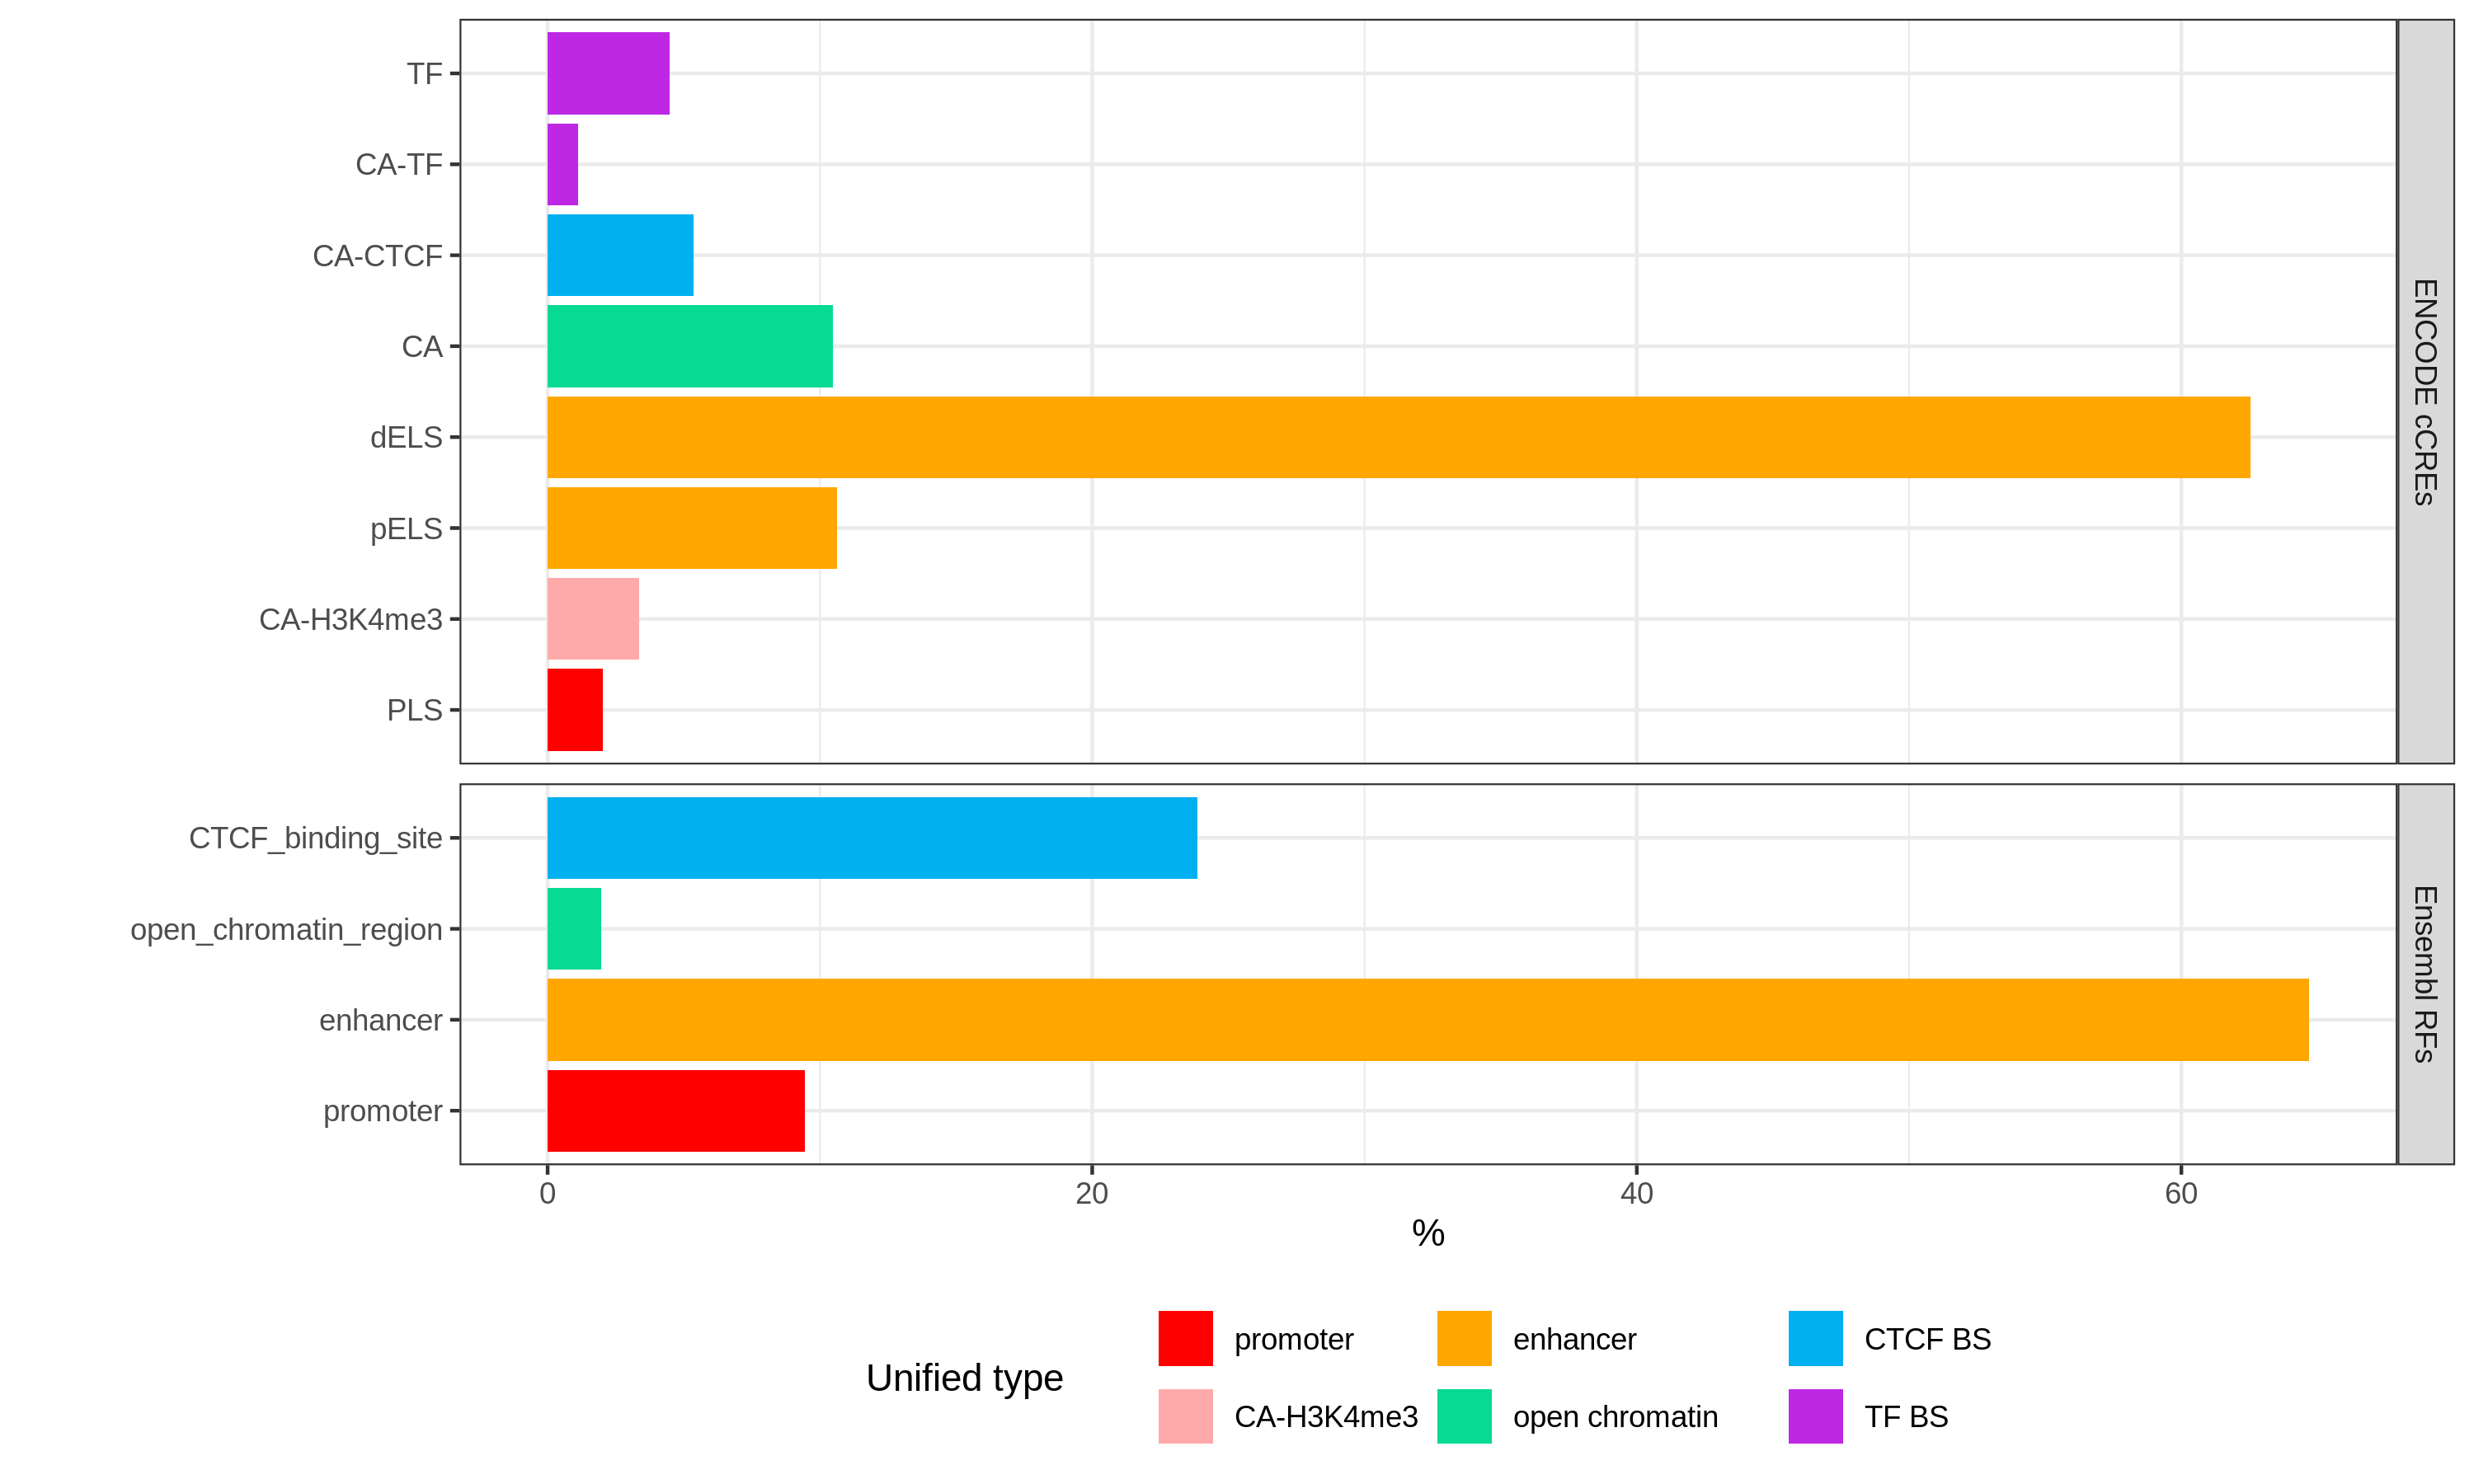

In [ ]:
options(
  repr.plot.width = 10,
  repr.plot.height = 6,
  repr.plot.res = 300
)

ENCODE_cCREs %>%
  as.data.frame() %>%
  group_by(type) %>%
  summarise(r =n() / length(ENCODE_cCREs)) %>%
  mutate(source = 'ENCODE cCREs',
         unified_type = unified_cre_type[type]) %>%
  bind_rows(EnsRegRFs %>%
              as.data.frame() %>%
              group_by(type) %>%
              summarise(r =n() / length(EnsRegRFs)) %>%
              mutate(source = 'Ensembl RFs',
                     unified_type = unified_cre_type[type])) %>%
  mutate(type = factor(type,
                               levels = c('promoter', 'PLS', 'CA-H3K4me3',
                                          'pELS', 'dELS', 'enhancer', 'CA',
                                          'open chromatin', 'open_chromatin_region',
                                          'CTCF_binding_site',
                                          'CA-CTCF', 'CA-TF', 'TF'))) %>%
  mutate(unified_type = factor(unified_type,
                               levels = c('promoter', 'CA-H3K4me3',
                                          'enhancer', 'open chromatin',
                                          'CTCF BS', 'TF BS'))) %>%
  ggplot() +
  geom_col(aes(x = type, y = r*100,
               fill = unified_type), width = 0.9) +
  coord_flip() +
  facet_grid(rows = vars(source), drop = TRUE,
             scales = 'free_y', space = 'free_y') +
  theme_bw()+
  scale_fill_manual(values = cCREs_colors) +
  theme(legend.position = 'bottom') +
  labs(y = '%', x = '', fill = 'Unified type')


In [ ]:
# user defined region
query_regions


GRanges object with 2 ranges and 1 metadata column:
      seqnames              ranges strand |                   name
         <Rle>           <IRanges>  <Rle> |            <character>
  [1]        8 127719386-127750748      * | query_region_1_8_127..
  [2]        8 127394142-127410068      * | query_region_2_8_127..
  -------
  seqinfo: 1 sequence from an unspecified genome; no seqlengths

### Combine open chromatin peaks for defining regulatory activity

In [ ]:
# Open chromatin peaks
encode_open_union <- make_open_chromatin_union(encode_atac, encode_dnase)

head(encode_open_union)


GRanges object with 6 ranges and 3 metadata columns:
      seqnames        ranges strand | evidence_source               assays
         <Rle>     <IRanges>  <Rle> |     <character>          <character>
  [1]        1   10257-10645      * |   ENCODE HCT116 ATAC-seq + DNase-seq
  [2]        1 180905-181984      * |   ENCODE HCT116 ATAC-seq + DNase-seq
  [3]        1 196421-196685      * |   ENCODE HCT116 ATAC-seq + DNase-seq
  [4]        1 268012-268080      * |   ENCODE HCT116 ATAC-seq + DNase-seq
  [5]        1 778324-779232      * |   ENCODE HCT116 ATAC-seq + DNase-seq
  [6]        1 779785-780011      * |   ENCODE HCT116 ATAC-seq + DNase-seq
               union_peak_id
                 <character>
  [1] ENCODE HCT116_union_..
  [2] ENCODE HCT116_union_..
  [3] ENCODE HCT116_union_..
  [4] ENCODE HCT116_union_..
  [5] ENCODE HCT116_union_..
  [6] ENCODE HCT116_union_..
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [ ]:

ensembl_open_union <- make_open_chromatin_union(ensembl_atac, ensembl_dnase)

head(ensembl_open_union)


Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': GL000221.1, KI270303.1, KI270310.1, KI270330.1, KI270411.1, KI270706.1, KI270711.1, KI270712.1, KI270721.1, KI270742.1, KI270743.1, KI270745.1, KI270747.1, KI270748.1, KI270754.1
  - in 'y': KI270725.1
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”


GRanges object with 6 ranges and 3 metadata columns:
      seqnames      ranges strand | evidence_source               assays
         <Rle>   <IRanges>  <Rle> |     <character>          <character>
  [1]        1  9958-10649      * |  Ensembl HCT116 ATAC-seq + DNase-seq
  [2]        1 10909-11529      * |  Ensembl HCT116 ATAC-seq + DNase-seq
  [3]        1 15535-15764      * |  Ensembl HCT116 ATAC-seq + DNase-seq
  [4]        1 26018-26324      * |  Ensembl HCT116 ATAC-seq + DNase-seq
  [5]        1 28658-30149      * |  Ensembl HCT116 ATAC-seq + DNase-seq
  [6]        1 36485-36863      * |  Ensembl HCT116 ATAC-seq + DNase-seq
               union_peak_id
                 <character>
  [1] Ensembl HCT116_union..
  [2] Ensembl HCT116_union..
  [3] Ensembl HCT116_union..
  [4] Ensembl HCT116_union..
  [5] Ensembl HCT116_union..
  [6] Ensembl HCT116_union..
  -------
  seqinfo: 76 sequences from an unspecified genome; no seqlengths

### Identify features in the query regions

In [ ]:
query_ENCODE_cCREs_hits <- findOverlaps(query_regions, ENCODE_cCREs,
                                        ignore.strand = TRUE)

query_EnsReg_RFs_hits <- findOverlaps(query_regions, EnsRegRFs,
                                        ignore.strand = TRUE)


ENCODE_cCREs_region_1 <- ENCODE_cCREs[subjectHits(query_ENCODE_cCREs_hits)[queryHits(query_ENCODE_cCREs_hits) == 1]]
ENCODE_cCREs_region_2 <- ENCODE_cCREs[subjectHits(query_ENCODE_cCREs_hits)[queryHits(query_ENCODE_cCREs_hits) == 2]]
ENCODE_cCREs_region_1 %>%
  as.data.frame() %>%
  mutate(region = mcols(query_regions)[,'name'][1]) %>%
  bind_rows(ENCODE_cCREs_region_2 %>%
              as.data.frame() %>%
              mutate(region = mcols(query_regions)[,'name'][2])) %>%
  mutate( unified_type = unified_cre_type[type]) -> ENCODE_cCREs_in_query



In [ ]:
print(paste('ENCODE cCREs in region', mcols(query_regions)[1, 'name'], ":", length(ENCODE_cCREs_region_1), sep = " "))

[1] "ENCODE cCREs in region query_region_1_8_127719386_127750748 : 66"


In [ ]:
print(paste('ENCODE cCREs in region', mcols(query_regions)[2, 'name'], ":", length(ENCODE_cCREs_region_2), sep = " "))

[1] "ENCODE cCREs in region query_region_2_8_127394142_127410068 : 30"


In [ ]:
EnsReg_RFs_region_1 <- EnsRegRFs[subjectHits(query_EnsReg_RFs_hits)[queryHits(query_EnsReg_RFs_hits) == 1]]
EnsReg_RFs_region_2 <- EnsRegRFs[subjectHits(query_EnsReg_RFs_hits)[queryHits(query_EnsReg_RFs_hits) == 2]]
EnsReg_RFs_region_1 %>%
  as.data.frame() %>%
  mutate(region = mcols(query_regions)[,'name'][1]) %>%
  bind_rows(EnsReg_RFs_region_2 %>%
              as.data.frame() %>%
              mutate(region = mcols(query_regions)[,'name'][2])) %>%
  mutate( unified_type = unified_cre_type[type]) -> EnsReg_in_query


In [ ]:
print(paste('Ensembl Regulatory Features in region', mcols(query_regions)[1, 'name'], ":", length(EnsReg_RFs_region_1), sep = " "))

[1] "Ensembl Regulatory Features in region query_region_1_8_127719386_127750748 : 21"


In [ ]:
print(paste('Ensembl Regulatory Features in region', mcols(query_regions)[2, 'name'], ":", length(EnsReg_RFs_region_2), sep = " "))

[1] "Ensembl Regulatory Features in region query_region_2_8_127394142_127410068 : 7"


#### Combine the features information in a single table

In [ ]:
ENCODE_cCREs_in_query %>%
  select(seqnames, start, end, name, type, unified_type, region) %>%
  mutate(source = 'ENCODE') %>%
  bind_rows(EnsReg_in_query %>%
              select(seqnames, start, end, ID, type, unified_type, region) %>%
              dplyr::rename(name = ID) %>%
              mutate(source = 'Ensembl')) -> CREs_in_query


### Number of features in the query regions

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by source, region, unified_type, and type.
ℹ Output is grouped by source, region, and unified_type.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(source, region, unified_type, type))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.


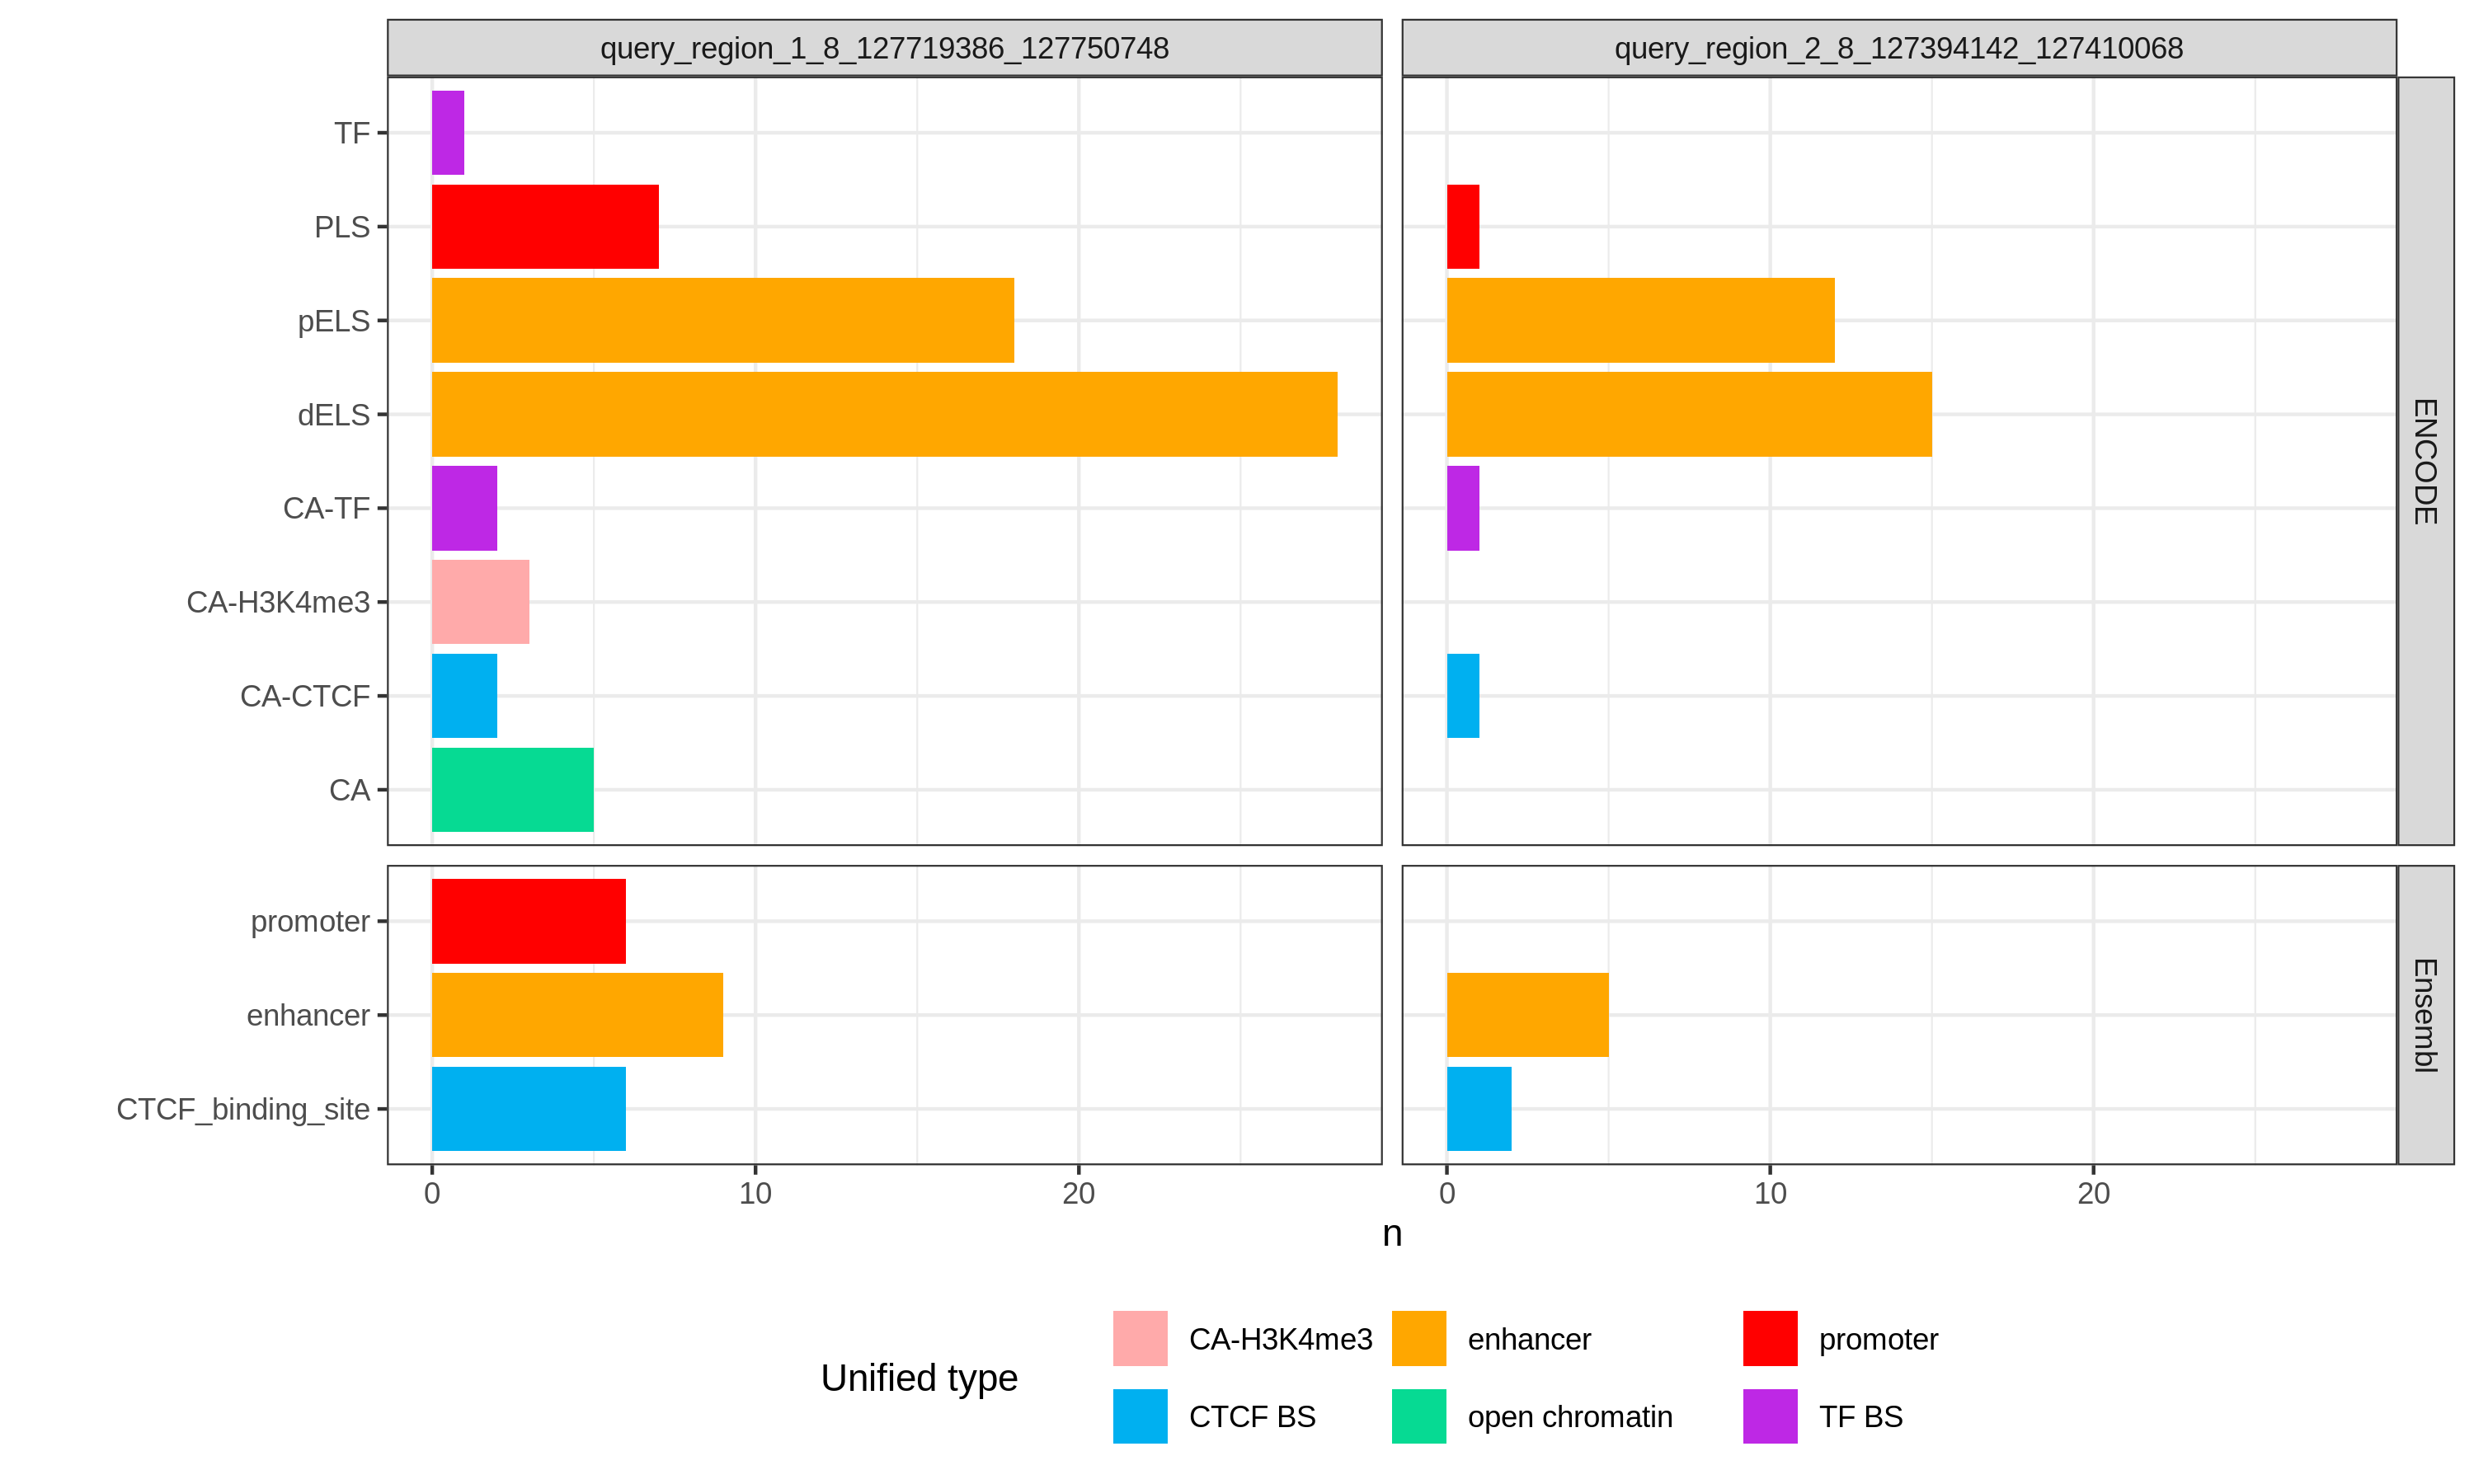

In [ ]:
options(
  repr.plot.width = 10,
  repr.plot.height = 6,
  repr.plot.res = 300
)

# Number of features per resource and region
CREs_in_query %>%
  group_by(source, region, unified_type, type) %>%
  summarise(n = n()) %>%
  ggplot() +
  geom_col(aes(x = type, y = n, fill = unified_type), width = 0.9) +
  coord_flip() +
  facet_grid(cols = vars(region), rows = vars(source), drop = TRUE,
             scales = 'free_y', space = 'free_y') +
  theme_bw()+
  scale_fill_manual(values = cCREs_colors) +
  theme(legend.position = 'bottom') +
  labs(y = 'n', x = '', fill = 'Unified type')

### Selecting promoters in the query region

In [ ]:
selected_feature_types <- c("promoter", "PLS")


CREs_in_query %>%
  filter(type %in% selected_feature_types) -> promoters_in_query

head(promoters_in_query)



,seqnames,start,end,name,type,unified_type,region,source
,<fct>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,8,127733990,127734338,EH38E3858721,PLS,promoter,query_region_1_8_127719386_127750748,ENCODE
2,8,127735100,127735447,EH38E3858722,PLS,promoter,query_region_1_8_127719386_127750748,ENCODE
3,8,127735612,127735762,EH38E3858723,PLS,promoter,query_region_1_8_127719386_127750748,ENCODE
4,8,127735820,127736017,EH38E3858724,PLS,promoter,query_region_1_8_127719386_127750748,ENCODE
5,8,127736052,127736398,EH38E3858725,PLS,promoter,query_region_1_8_127719386_127750748,ENCODE
6,8,127737300,127737554,EH38E3858729,PLS,promoter,query_region_1_8_127719386_127750748,ENCODE


### Identifying active promoters in HCT116

In [ ]:
# Identify promoters that are active in HCT116 by overlapping them with open
# chromatin peaks

ENCODE_promoters_in_query_oc_hits <- findOverlaps(
  makeGRangesFromDataFrame(promoters_in_query %>%
                             filter(source == 'ENCODE'), keep.extra.columns = TRUE),
  encode_open_union, ignore.strand = TRUE)

EnsReg_promoters_in_query_oc_hits <- findOverlaps(
  makeGRangesFromDataFrame(promoters_in_query %>%
                             filter(source == 'Ensembl'), keep.extra.columns = TRUE),
  ensembl_open_union, ignore.strand = TRUE)
promoters_in_query %>%
  filter(source == "ENCODE") %>%
  dplyr::slice(queryHits(ENCODE_promoters_in_query_oc_hits)) %>%
  pull(name) -> active_ENCODE_promoters

promoters_in_query %>%
  filter(source == "Ensembl") %>%
  dplyr::slice(queryHits(EnsReg_promoters_in_query_oc_hits)) %>%
  pull(name) -> active_Ensembl_promoters

promoters_in_query %>%
  filter(name %in% c(active_ENCODE_promoters,
                     active_Ensembl_promoters )) -> active_promoters_in_query

In [ ]:
active_promoters_in_query

seqnames,start,end,name,type,unified_type,region,source
<fct>,<int>,<int>,<chr>,<chr>,<fct>,<chr>,<chr>
8,127733990,127734338,EH38E3858721,PLS,promoter,query_region_1_8_127719386_127750748,ENCODE
8,127735100,127735447,EH38E3858722,PLS,promoter,query_region_1_8_127719386_127750748,ENCODE
8,127735612,127735762,EH38E3858723,PLS,promoter,query_region_1_8_127719386_127750748,ENCODE
8,127735820,127736017,EH38E3858724,PLS,promoter,query_region_1_8_127719386_127750748,ENCODE
8,127736052,127736398,EH38E3858725,PLS,promoter,query_region_1_8_127719386_127750748,ENCODE
8,127400343,127400576,EH38E3858445,PLS,promoter,query_region_2_8_127394142_127410068,ENCODE
8,127733946,127734457,ENSR8_BXCG3,promoter,promoter,query_region_1_8_127719386_127750748,Ensembl
8,127735249,127735669,ENSR8_93TNWH,promoter,promoter,query_region_1_8_127719386_127750748,Ensembl
8,127735795,127736241,ENSR8_93TNWM,promoter,promoter,query_region_1_8_127719386_127750748,Ensembl


### Save output files

In [ ]:

rtracklayer::export(
  GRanges(active_promoters_in_query),
  file.path(paths$output_dir, "GRCh38_hct116_active_promoters_R.bed"),
  format = "BED"
)
save.image(file = file.path(paths$output_dir, "session4_GRCh38.RData"),
           compress = 'xz')
